In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df=pd.read_csv("marketing_campaign_performance_10000.csv")
df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CampaignID   10000 non-null  object 
 1   StartDate    10000 non-null  object 
 2   EndDate      10000 non-null  object 
 3   Channel      10000 non-null  object 
 4   Impressions  10000 non-null  int64  
 5   Clicks       10000 non-null  int64  
 6   Leads        10000 non-null  int64  
 7   Conversions  10000 non-null  int64  
 8   Cost_USD     10000 non-null  float64
 9   Revenue_USD  10000 non-null  float64
 10  ROI          10000 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 859.5+ KB


In [22]:
df.isnull().sum()

CampaignID     0
StartDate      0
EndDate        0
Channel        0
Impressions    0
Clicks         0
Leads          0
Conversions    0
Cost_USD       0
Revenue_USD    0
ROI            0
dtype: int64

In [23]:
df["StartDate"]= pd.to_datetime(df["StartDate"])
df["EndDate"]= pd.to_datetime(df["EndDate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CampaignID   10000 non-null  object        
 1   StartDate    10000 non-null  datetime64[ns]
 2   EndDate      10000 non-null  datetime64[ns]
 3   Channel      10000 non-null  object        
 4   Impressions  10000 non-null  int64         
 5   Clicks       10000 non-null  int64         
 6   Leads        10000 non-null  int64         
 7   Conversions  10000 non-null  int64         
 8   Cost_USD     10000 non-null  float64       
 9   Revenue_USD  10000 non-null  float64       
 10  ROI          10000 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(4), object(2)
memory usage: 859.5+ KB


In [24]:
df["kampanyaSuresi"]= (df["EndDate"] - df["StartDate"]).dt.days
df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,kampanyaSuresi
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12,6
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96,9
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90,8
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76,13
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86,9


In [25]:
#ne kadar harcadık ne kadar kişi satın aldı "cost per acquisition"
df["CPA"]= df["Cost_USD"] / df["Conversions"]
df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,kampanyaSuresi,CPA
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12,6,0.195285
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96,9,1.587230
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90,8,0.294492
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76,13,3.662661
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86,9,8.735363


In [26]:
#tıklayanların ne kadarı satın aldı 
df["ConversionsRate"]= df["Conversions"] / df["Clicks"]
df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,kampanyaSuresi,CPA,ConversionsRate
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12,6,0.195285,0.230941
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96,9,1.587230,0.157692
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90,8,0.294492,0.206154
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76,13,3.662661,0.127994
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86,9,8.735363,0.135981


In [27]:
df.describe()

,StartDate,EndDate,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,kampanyaSuresi,CPA,ConversionsRate
count,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025-07-01 10:03:47.520000,2025-07-11 09:10:22.079999744,152260.637900,8338.993300,2512.463600,1010.700000,2552.356991,5102.648930,1.001576,9.962900,10.247006,0.120940
min,2025-01-01 00:00:00,2025-01-06 00:00:00,5043.000000,72.000000,10.000000,4.000000,100.230000,113.640000,0.000000,5.000000,0.021786,0.020548
25%,2025-04-03 00:00:00,2025-04-13 00:00:00,78956.000000,2981.000000,779.000000,295.000000,1319.622500,2385.742500,0.500000,7.000000,1.324412,0.074104
50%,2025-06-30 00:00:00,2025-07-10 00:00:00,151505.500000,6588.500000,1777.000000,670.000000,2529.675000,4659.365000,0.990000,10.000000,3.266165,0.110669
75%,2025-10-01 00:00:00,2025-10-12 00:00:00,225853.250000,12404.250000,3550.250000,1391.000000,3821.307500,7241.245000,1.510000,13.000000,8.450725,0.160843
max,2025-12-31 00:00:00,2026-01-15 00:00:00,299997.000000,29578.000000,13833.000000,7987.000000,4998.420000,14871.340000,2.000000,15.000000,1225.450000,0.298902
std,NaN,NaN,85251.707621,6546.326431,2321.031302,1019.402613,1427.694545,3309.326705,0.578806,3.157106,31.511206,0.059217


In [28]:
df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,kampanyaSuresi,CPA,ConversionsRate
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12,6,0.195285,0.230941
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96,9,1.587230,0.157692
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90,8,0.294492,0.206154
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76,13,3.662661,0.127994
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86,9,8.735363,0.135981


In [29]:
df.groupby("Channel")[["ROI","CPA","ConversionsRate"]].mean().sort_values("ConversionsRate")

,ROI,CPA,ConversionsRate
Channel,,,
Influencer,0.997529,9.111069,0.119889
Display,0.999304,10.804092,0.121116
Search,1.013389,10.894869,0.121150
Email,1.009990,10.130729,0.121220
Social,0.988020,10.333181,0.121368


Geri dönüş olarak en değerli müşteri Social kampanyaları fakat "ROI" kısmına bakarsak Social
kampanyaları bizi zarara sokuyor bu bakımdan en karlı olan Search kampanyaları ve müşteri geri
dönüşü de en fazla olan araç

In [30]:
df.groupby("kampanyaSuresi")[["ROI","CPA","ConversionsRate","Cost_USD"]].mean().sort_values("ROI")

,ROI,CPA,ConversionsRate,Cost_USD
kampanyaSuresi,,,,
7,0.966638,9.932582,0.121787,2607.492797
5,0.979541,10.745865,0.120467,2454.019851
12,0.980500,10.084329,0.122349,2610.762228
9,0.986260,10.021449,0.119911,2576.447525
13,0.994424,11.203048,0.120290,2545.018025
11,1.010603,11.362391,0.117412,2565.503311
8,1.011882,8.976534,0.121797,2500.768895
10,1.013223,11.631794,0.119736,2584.089084
6,1.014763,10.531670,0.123907,2569.061507


Bize en karlı olarak dönen "ROI" 14 günlük kampanyalar fakat harcanan para karşılığında en
çok müşteri kazanan kampanya 10 günlük kampanyalar

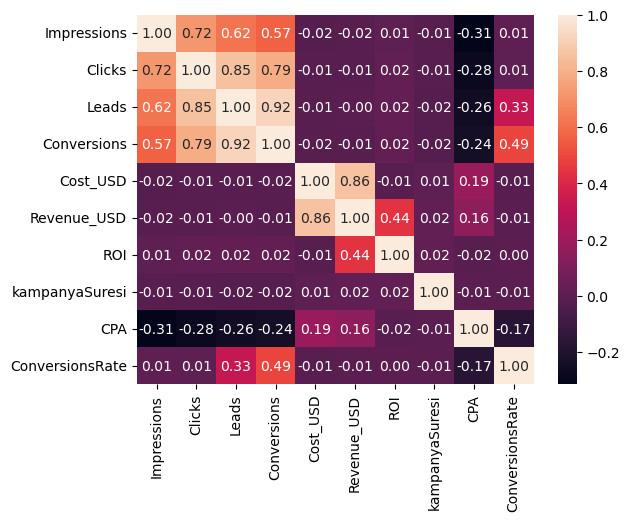

In [31]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt=".2f")
plt.show()

Harcanan para ile geri dönen para arasında kuvvetli bir korelasyon var

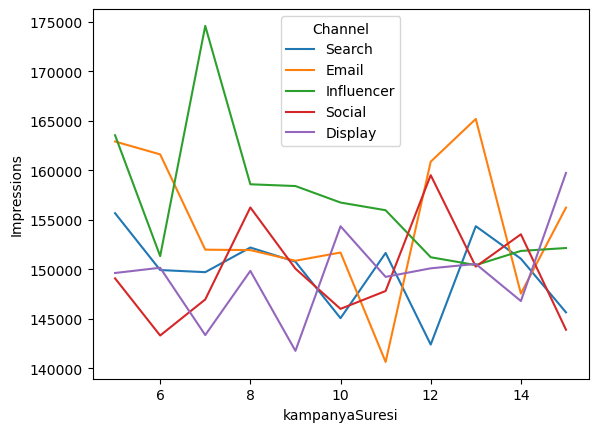

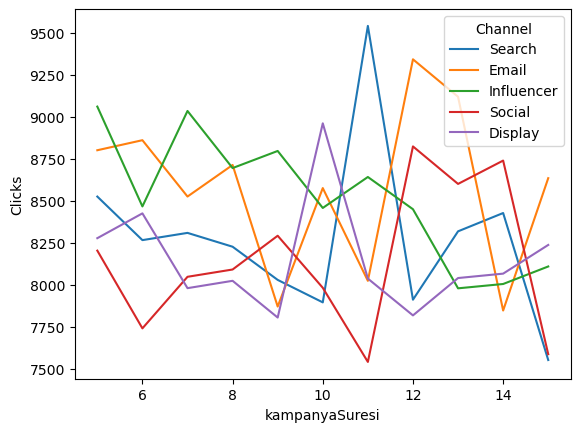

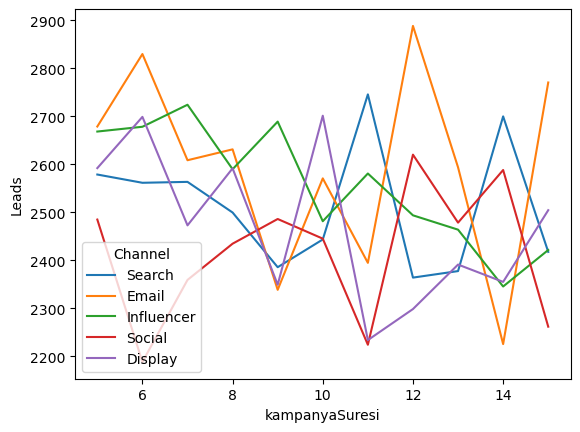

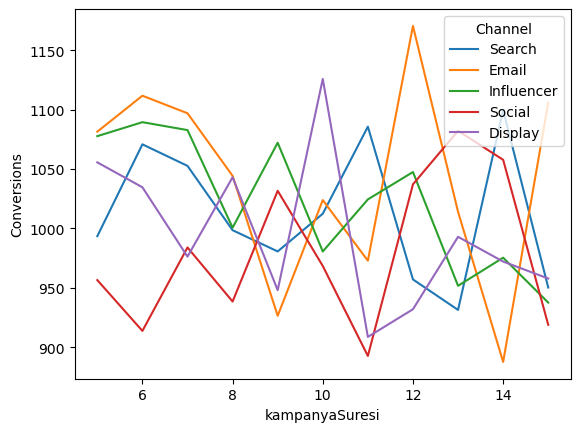

In [32]:
list1=["Impressions","Clicks","Leads","Conversions"]
for i in list1:
    plt.figure()
    sns.lineplot(data=df,
                 y=i,x="kampanyaSuresi",
                 hue="Channel",
                 errorbar=None,
                 markers="o")
    plt.show()

In [33]:
df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,kampanyaSuresi,CPA,ConversionsRate
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12,6,0.195285,0.230941
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96,9,1.587230,0.157692
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90,8,0.294492,0.206154
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76,13,3.662661,0.127994
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86,9,8.735363,0.135981


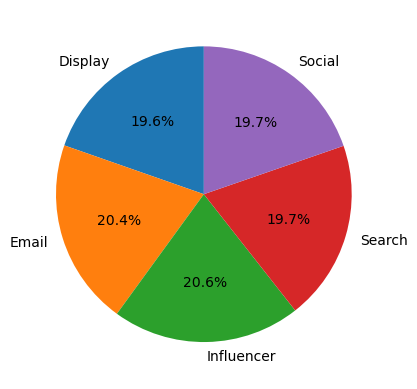

In [34]:
group1=df.groupby("Channel")["Impressions"].mean()
plt.pie(x=group1.values,
        labels=group1.index,
        autopct="%1.1f%%",
        startangle=90)
plt.show()

Küçük bir farkla en fazla görüntülenmeyi influancer sayesinde yapıyoruz

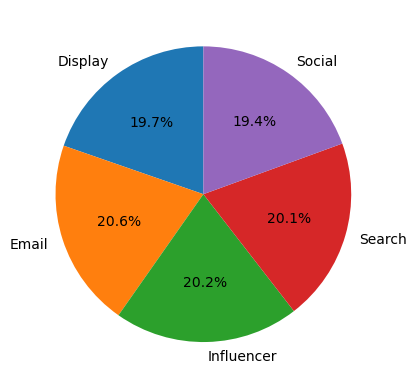

In [35]:
group2=df.groupby("Channel")["Conversions"].mean()
plt.pie(x=group2.values,
        labels=group2.index, 
        autopct="%1.1f%%",
        startangle=90)
plt.show()

Küçük bir farkla e mail yoluyla daha fazla müşteri kazanıyoruz

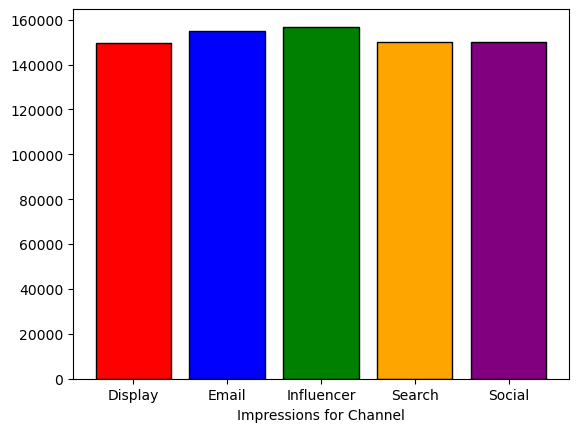

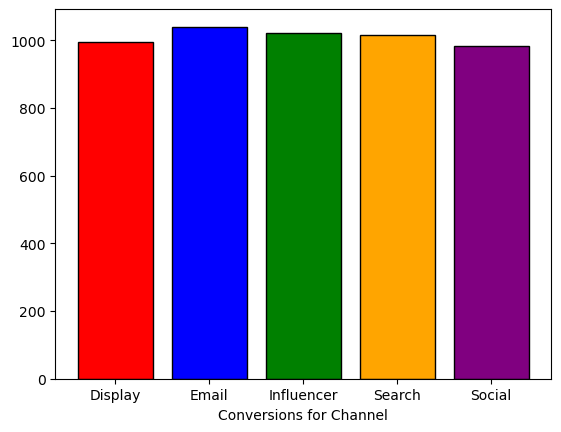

In [36]:
color=["red","blue","green","orange","purple"]


plt.bar(group1.index,
        group1.values,
        color=color,
        edgecolor="black",
        )
plt.xlabel("Impressions for Channel")
plt.show()


plt.bar(group2.index,
        group2.values,
       color=color,
       edgecolor="black")
plt.xlabel("Conversions for Channel")
plt.show()

In [41]:
df["Cost_USD_Seg"]=pd.cut(df["Cost_USD"],bins=[0,1000,3000,np.inf],labels=["Low","Medium","High"])
df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,kampanyaSuresi,CPA,ConversionsRate,Cost_USD_Seg
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12,6,0.195285,0.230941,Medium
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96,9,1.587230,0.157692,High
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90,8,0.294492,0.206154,Medium
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76,13,3.662661,0.127994,Medium
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86,9,8.735363,0.135981,High


In [43]:
df.groupby("Cost_USD_Seg")[["ROI","Conversions"]].mean()

C:\Users\tolga\AppData\Local\Temp\ipykernel_7740\2642089038.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Cost_USD_Seg")[["ROI","Conversions"]].mean()


,ROI,Conversions
Cost_USD_Seg,,
Low,1.010136,1005.337684
Medium,1.003846,1032.960808
High,0.995391,990.570195


Harcama arttıkça ROI düşüyor az bütçeli kampanyalar geri dönüm açısından en karlı fakat bize en çok müşteriyi orta ölçekte para
harcadığımız kampanyalar getiriyor

In [64]:
result = df.groupby("StartDate")["ROI"].mean()
filtered = result[result> 1]
filtered.sort_values( ascending=False)

StartDate
2025-01-06    1.311364
2025-06-08    1.280526
2025-12-15    1.278710
2025-08-18    1.277391
2025-04-24    1.274643
                ...   
2025-12-28    1.005000
2025-11-13    1.001905
2025-07-04    1.001579
2025-03-17    1.001471
2025-06-11    1.000690
Name: ROI, Length: 186, dtype: float64

Ayın 6'sında başlayan kampanyalar geri dönüşü en iyi olan kampanyalar

In [69]:
print(df.sort_values(by="ROI",ascending=False).head(10))

     CampaignID  StartDate    EndDate     Channel  Impressions  Clicks  Leads  \
3078  CAMP03079 2025-10-30 2025-11-11     Display       103214    7032   2294   
5241  CAMP05242 2025-08-06 2025-08-13       Email         6971     677    103   
3243  CAMP03244 2025-02-12 2025-02-27  Influencer        52391    4507   2098   
142   CAMP00143 2025-02-21 2025-03-05      Search        14554    1027    136   
3000  CAMP03001 2025-10-29 2025-11-08      Search        75805     977    433   
1573  CAMP01574 2025-12-04 2025-12-15     Display       239452    6580   1054   
7907  CAMP07908 2025-03-17 2025-03-22  Influencer       278005    6856   1741   
3801  CAMP03802 2025-06-12 2025-06-25       Email       264832   18316   2786   
9887  CAMP09888 2025-10-06 2025-10-19       Email       280260   10520   3371   
4897  CAMP04898 2025-03-05 2025-03-18       Email       239607   20939   4527   

      Conversions  Cost_USD  Revenue_USD  ROI  kampanyaSuresi         CPA  \
3078          876   3317.83    

En iyi geri dönüş sağlayan 10 kampanya detayları

In [71]:
print(df.sort_values(by="ROI").head(10))

     CampaignID  StartDate    EndDate     Channel  Impressions  Clicks  Leads  \
6278  CAMP06279 2025-06-22 2025-07-01      Social        78071    7712   2951   
8882  CAMP08883 2025-12-19 2025-12-29     Display       287309    4136    731   
5227  CAMP05228 2025-12-05 2025-12-14     Display        56243    4444   1864   
2975  CAMP02976 2025-07-29 2025-08-08  Influencer        90770    3030    926   
673   CAMP00674 2025-08-21 2025-09-02     Display        78400    4775   1176   
8472  CAMP08473 2025-04-04 2025-04-16     Display       264249    6850   2048   
2291  CAMP02292 2025-02-27 2025-03-04      Search        12589     515    149   
6103  CAMP06104 2025-09-28 2025-10-03       Email       214033    2334    933   
4550  CAMP04551 2025-06-14 2025-06-23      Search       158352    8008   3617   
112   CAMP00113 2025-11-24 2025-11-29  Influencer       154651   14864   3210   

      Conversions  Cost_USD  Revenue_USD  ROI  kampanyaSuresi        CPA  \
6278          954   3495.50     

Geri dönüşü en kötü olan kampanyalar

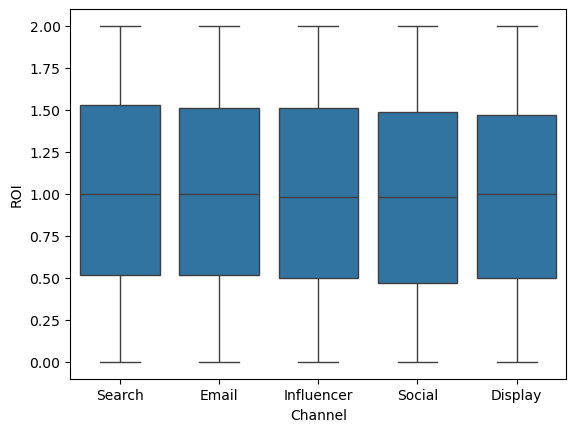

In [72]:
sns.boxplot(x="Channel", y="ROI", data=df)
plt.show()